# Vanishing and exploding gradients

**Learning objective:** See why repeatedly multiplying temporal Jacobians can shrink or amplify gradients exponentially.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:33.545150: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974813.560562    3011 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974813.564938    3011 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:35.224319: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,0.7 (vanish),1.0 (stable),1.3 (explode)
1,7.000000e-01,1.0,1.300000
5,1.680700e-01,1.0,3.712930
10,2.824752e-02,1.0,13.785849
20,7.979227e-04,1.0,190.049638
40,6.366806e-07,1.0,36118.864808


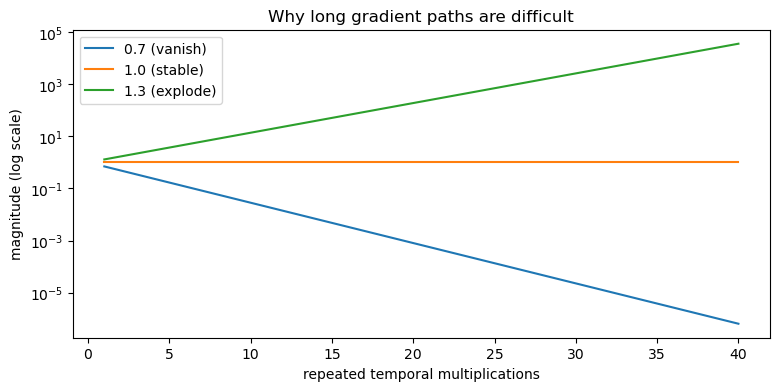

In [2]:
steps=np.arange(1,41)
curves={"0.7 (vanish)":0.7**steps,"1.0 (stable)":1.0**steps,"1.3 (explode)":1.3**steps}
df=pd.DataFrame(curves,index=steps); display(df.iloc[[0,4,9,19,39]])
plt.figure(figsize=(9,4))
for name,v in curves.items(): plt.semilogy(steps,np.abs(v),label=name)
plt.xlabel("repeated temporal multiplications"); plt.ylabel("magnitude (log scale)"); plt.legend(); plt.title("Why long gradient paths are difficult"); plt.show()


LSTM and GRU architectures add gated paths that make retaining or forgetting information easier to learn. Gradient clipping is another practical safeguard against explosions, but it does not solve memory design by itself.


In [3]:
opt=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
print("Example optimizer with global per-variable norm clipping:", opt.get_config()["clipnorm"])


Example optimizer with global per-variable norm clipping: 1.0
